**A. Understand your data:**

1.Import the database as pandas dataframe
2.How does the data look like?
3.How big the data is?
4.What is the data type of columns?
5.How does the data look like mathematically?
6.Are there any missing values?
7.Are there any duplicated values?
8.List the top 10 happiest country
9.List the 10 least happiest country

10.Find rows with null values and delete those rows.

In [137]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL.ImageColor import colormap
from matplotlib.pyplot import xticks
from mlxtend.plotting import stacked_barplot
from pandas.conftest import ascending

In [138]:
df = pd.read_csv('World Happiness Report.csv')
df.sample(5)

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
134,Chad,137,3.936,0.438013,0.953856,0.041135,0.162342,0.216114,0.053582,2.071238,67.9,Africa
31,Thailand,32,6.424,1.127869,1.425792,0.647239,0.580201,0.572123,0.031613,2.039508,93.7,Asia-Pacific
144,South Sudan,147,3.591,0.397249,0.601323,0.163486,0.147062,0.285671,0.116794,1.879567,NaN,Africa
79,Indonesia,81,5.262,0.995539,1.274445,0.492346,0.443323,0.611705,0.015317,1.429477,73.3,Asia-Pacific
63,Cyprus,65,5.621,1.355938,1.131363,0.844715,0.355112,0.271254,0.041238,1.621249,88.7,Eastern Europe


In [139]:
df.shape

(153, 12)

In [140]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           153 non-null    str    
 1   Happiness Rank    153 non-null    int64  
 2   Happiness Score   153 non-null    float64
 3   Economy           153 non-null    float64
 4   Family            153 non-null    float64
 5   Health            153 non-null    float64
 6   Freedom           153 non-null    float64
 7   Generosity        153 non-null    float64
 8   Corruption        153 non-null    float64
 9   Dystopia          153 non-null    float64
 10  Job Satisfaction  151 non-null    float64
 11  Region            153 non-null    str    
dtypes: float64(9), int64(1), str(2)
memory usage: 14.5 KB


In [141]:
df.describe()

,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction
count,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,151.000000
mean,78.169935,5.349281,0.982433,1.186630,0.550117,0.408489,0.245324,0.123179,1.853072,75.209934
std,45.008741,1.134997,0.421901,0.288441,0.237769,0.150744,0.134395,0.102133,0.499490,12.962365
min,1.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914,44.400000
25%,40.000000,4.497000,0.659517,1.041990,0.364509,0.300741,0.153075,0.057070,1.597970,68.950000
50%,78.000000,5.279000,1.064578,1.251826,0.606042,0.437454,0.231503,0.089848,1.832910,78.100000
75%,117.000000,6.098000,1.315175,1.416404,0.719217,0.518631,0.322228,0.153066,2.150801,85.100000
max,155.000000,7.537000,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485,95.100000


In [142]:
df.isnull().sum()

Country             0
Happiness Rank      0
Happiness Score     0
Economy             0
Family              0
Health              0
Freedom             0
Generosity          0
Corruption          0
Dystopia            0
Job Satisfaction    2
Region              0
dtype: int64

In [143]:
df.duplicated().sum()

np.int64(0)

In [144]:
df.corr(numeric_only=True)

,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction
Happiness Rank,1.000000,-0.992782,-0.811916,-0.738380,-0.779191,-0.558380,-0.138480,-0.413378,-0.482534,-0.814535
Happiness Score,-0.992782,1.000000,0.811194,0.753815,0.780496,0.576027,0.160010,0.435854,0.474300,0.812873
Economy,-0.811916,0.811194,1.000000,0.688701,0.841900,0.375043,-0.017310,0.357817,0.018464,0.700662
Family,-0.738380,0.753815,0.688701,1.000000,0.612003,0.425937,0.046005,0.233749,0.073697,0.623266
Health,-0.779191,0.780496,0.841900,0.612003,1.000000,0.354683,0.065979,0.285952,0.049716,0.704795
Freedom,-0.558380,0.576027,0.375043,0.425937,0.354683,1.000000,0.312880,0.497729,0.089590,0.500655
Generosity,-0.138480,0.160010,-0.017310,0.046005,0.065979,0.312880,1.000000,0.292364,-0.103064,0.220032
Corruption,-0.413378,0.435854,0.357817,0.233749,0.285952,0.497729,0.292364,1.000000,-0.016260,0.337131
Dystopia,-0.482534,0.474300,0.018464,0.073697,0.049716,0.089590,-0.103064,-0.016260,1.000000,0.281655
Job Satisfaction,-0.814535,0.812873,0.700662,0.623266,0.704795,0.500655,0.220032,0.337131,0.281655,1.000000


In [145]:
df.sort_values(by="Happiness Rank", ascending=True).head(10)

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,94.6,Western Europe
1,Denmark,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,93.5,Western Europe
2,Iceland,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,94.5,Western Europe
3,Switzerland,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,93.7,Western Europe
4,Finland,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,91.2,Western Europe
5,Netherlands,6,7.377,1.503945,1.428939,0.810696,0.585384,0.470490,0.282662,2.294804,93.8,Western Europe
6,Canada,7,7.316,1.479204,1.481349,0.834558,0.611101,0.435540,0.287372,2.187264,90.5,North America
7,New Zealand,8,7.314,1.405706,1.548195,0.816760,0.614062,0.500005,0.382817,2.046456,88.6,Asia-Pacific
8,Sweden,9,7.284,1.494387,1.478162,0.830875,0.612924,0.385399,0.384399,2.097538,92.7,Western Europe
9,Australia,10,7.284,1.484415,1.510042,0.843887,0.601607,0.477699,0.301184,2.065211,89.2,Asia-Pacific


In [146]:
df.sort_values(by="Happiness Rank", ascending=False).head(10)

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
152,Central African Republic,155,2.693,0.000000,0.000000,0.018773,0.270842,0.280876,0.056565,2.066005,70.4,Africa
151,Burundi,154,2.905,0.091623,0.629794,0.151611,0.059901,0.204435,0.084148,1.683024,54.3,Africa
150,Tanzania,153,3.349,0.511136,1.041990,0.364509,0.390018,0.354256,0.066035,0.621130,57.8,Africa
149,Syria,152,3.462,0.777153,0.396103,0.500533,0.081539,0.493664,0.151347,1.061574,62.7,Asia-Pacific
148,Rwanda,151,3.471,0.368746,0.945707,0.326425,0.581844,0.252756,0.455220,0.540061,51.7,Africa
147,Togo,150,3.495,0.305445,0.431883,0.247106,0.380426,0.196896,0.095665,1.837229,44.8,Africa
146,Guinea,149,3.507,0.244550,0.791245,0.194129,0.348588,0.264815,0.110938,1.552312,55.1,Africa
145,Liberia,148,3.533,0.119042,0.872118,0.229918,0.332881,0.266550,0.038948,1.673286,56.6,Africa
144,South Sudan,147,3.591,0.397249,0.601323,0.163486,0.147062,0.285671,0.116794,1.879567,NaN,Africa
143,Yemen,146,3.593,0.591683,0.935382,0.310081,0.249464,0.104125,0.056767,1.345601,58.9,Asia-Pacific


In [147]:
df[df.isnull().any(axis=1)]

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
59,North Cyprus,61,5.810,1.346911,1.186303,0.834647,0.471204,0.266846,0.155353,1.549158,NaN,Eastern Europe
144,South Sudan,147,3.591,0.397249,0.601323,0.163486,0.147062,0.285671,0.116794,1.879567,NaN,Africa


In [148]:
df.dropna(inplace=True)

In [149]:
df.isnull().sum()

Country             0
Happiness Rank      0
Happiness Score     0
Economy             0
Family              0
Health              0
Freedom             0
Generosity          0
Corruption          0
Dystopia            0
Job Satisfaction    0
Region              0
dtype: int64

**B.Indexing and grouping:**

1. Use the column 'Region' to create a separate DataFrame containing the data points from each of the six regions: North America, Latin America, Western Europe, Eastern Europe, Asia Pacific, Africa.
2. Compute the mean happiness score for each region and rank the regions from most happy to least happy.
3. Compute the number of countries in each region that have a happiness score above 6.0.

In [150]:
df_region = df.groupby('Region')
df_region

In [151]:
df_region.describe()['Happiness Score'].sort_values(by='mean', ascending=True)

,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
Europe,1.0,4.096000,NaN,4.096,4.09600,4.0960,4.09600,4.096
Africa,43.0,4.254581,0.682470,2.693,3.80150,4.1900,4.63450,5.872
Asia-Pacific,43.0,5.358326,0.955062,3.462,4.65000,5.2690,6.02750,7.314
Eastern Europe,21.0,5.498952,0.402033,4.644,5.23700,5.5690,5.83800,6.098
Latin America,22.0,5.957818,0.750925,3.603,5.54850,6.0395,6.45400,7.079
Western Europe,19.0,6.880474,0.611070,5.195,6.56800,6.9510,7.42300,7.537
North America,2.0,7.154500,0.228395,6.993,7.07375,7.1545,7.23525,7.316


In [152]:
df[df['Region']=='Europe']

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
129,Ukraine,132,4.096,0.894652,1.394538,0.575904,0.122975,0.270061,0.023029,0.814382,72.3,Europe


In [153]:
df = df.replace('Europe', 'Eastern Europe')
df_region = df.groupby('Region')

In [154]:
df_region.describe()['Happiness Score'].sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
North America,2.0,7.154500,0.228395,6.993,7.07375,7.1545,7.23525,7.316
Western Europe,19.0,6.880474,0.611070,5.195,6.56800,6.9510,7.42300,7.537
Latin America,22.0,5.957818,0.750925,3.603,5.54850,6.0395,6.45400,7.079
Eastern Europe,22.0,5.435182,0.493357,4.096,5.22950,5.4820,5.83475,6.098
Asia-Pacific,43.0,5.358326,0.955062,3.462,4.65000,5.2690,6.02750,7.314
Africa,43.0,4.254581,0.682470,2.693,3.80150,4.1900,4.63450,5.872


In [155]:
df['Region'].value_counts()

Region
Asia-Pacific      43
Africa            43
Latin America     22
Eastern Europe    22
Western Europe    19
North America      2
Name: count, dtype: int64

I have created 6 new dataframe according to region.

In [156]:
df_AP= df[df['Region']=='Asia-Pacific']
df_A = df[df['Region']=='Africa']
df_LA = df[df['Region']=='Latin America']
df_EU = df[df['Region']=='Eastern Europe']
df_WU = df[df['Region']=='Western Europe']
df_NA = df[df['Region']=='North America']

In [157]:
len(df_AP[df_AP['Happiness Score']>6])

11

In [158]:
len(df_A[df_A['Happiness Score']>6])

0

In [159]:
len(df_LA[df_LA['Happiness Score']>6])

13

In [160]:
len(df_EU[df_EU['Happiness Score']>6])

1

In [161]:
len(df_WU[df_WU['Happiness Score']>6])

17

In [162]:
len(df_NA[df_NA['Happiness Score']>6])

2

In [163]:
df[df['Region']=='North America']

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
6,Canada,7,7.316,1.479204,1.481349,0.834558,0.611101,0.435540,0.287372,2.187264,90.5,North America
13,United States,14,6.993,1.546259,1.419921,0.774287,0.505741,0.392579,0.135639,2.218113,85.3,North America


**C. Happiness Score Analysis:**

1.Which country has the highest happiness score?
2.Which country has the lowest happiness score?
3.What is the average happiness score of all countries?

Which country has the highest happiness score?

In [164]:
df.sort_values(by='Happiness Score', ascending=False).head(1)

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,94.6,Western Europe


Which country has the lowest happiness score?

In [165]:
df.sort_values(by='Happiness Score', ascending=True).head(1)

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
152,Central African Republic,155,2.693,0.0,0.0,0.018773,0.270842,0.280876,0.056565,2.066005,70.4,Africa


What is the average happiness score of all countries?

In [166]:
df['Happiness Score'].mean()

np.float64(5.357874172417219)

**D.Region-Based Analysis:**

1.What is the average happiness score for each region?
2.What is the highest happiness score of each region?
3.Which region has the highest average happiness score?
4.How many countries belong to each region?

In [167]:
print("North America:", df_NA['Happiness Score'].mean())
print("Western Europe:", df_WU['Happiness Score'].mean())
print("Eastern Europe:", df_EU['Happiness Score'].mean())
print("Latin America:", df_LA['Happiness Score'].mean())
print("Asia Pacific:", df_AP['Happiness Score'].mean())
print("Asia:", df_A['Happiness Score'].mean())

North America: 7.154500008
Western Europe: 6.880473714157894
Eastern Europe: 5.435181812863637
Latin America: 5.957818193863637
Asia Pacific: 5.358325553465116
Asia: 4.254581407046512


What is the highest happiness score of each region?

In [168]:
df_region['Happiness Score'].max()

Region
Africa            5.872
Asia-Pacific      7.314
Eastern Europe    6.098
Latin America     7.079
North America     7.316
Western Europe    7.537
Name: Happiness Score, dtype: float64

Which region has the highest average happiness score?

In [169]:
df_region['Happiness Score'].mean().sort_values(ascending=False).head(1)

Region
North America    7.1545
Name: Happiness Score, dtype: float64

In [170]:
na = df_NA['Happiness Score'].mean()
wu = df_WU['Happiness Score'].mean()
eu = df_EU['Happiness Score'].mean()
la = df_LA['Happiness Score'].mean()
ap = df_AP['Happiness Score'].mean()

print(max(na, wu, eu, la, ap))

7.154500008


How many countries belong to each region?

In [171]:
df['Region'].value_counts()

Region
Asia-Pacific      43
Africa            43
Latin America     22
Eastern Europe    22
Western Europe    19
North America      2
Name: count, dtype: int64

**E.Feature-Based Analysis:**

1.Which country has the highest GDP per capita?
2.Which country has the highest social support?
3.Which country has the highest life expectancy?
4.Which country has the lowest freedom?

In [172]:
df.loc[df['Economy'].idxmax()]

Country                    Qatar
Happiness Rank                35
Happiness Score            6.375
Economy                 1.870766
Family                  1.274297
Health                  0.710098
Freedom                 0.604131
Generosity              0.330474
Corruption              0.439299
Dystopia                1.145464
Job Satisfaction            87.8
Region              Asia-Pacific
Name: 33, dtype: object

In [173]:
df.loc[df['Economy'].idxmax(),['Country','Economy']]

Country       Qatar
Economy    1.870766
Name: 33, dtype: object

Which country has the highest social support (family)?

In [174]:
df.loc[df['Family'].idxmax(),['Country','Family']]

Country     Iceland
Family     1.610574
Name: 2, dtype: object

Which country has the highest life expectancy?

In [175]:
df.loc[df['Health'].idxmax(),['Country','Health']]

Country    Singapore
Health      0.949492
Name: 25, dtype: object

Which country has the lowest freedom to make life choices?

In [176]:
df.loc[df['Freedom'].idxmin(),['Country','Freedom']]

Country    Angola
Freedom       0.0
Name: 137, dtype: object

**F.Correlation & Relationship:**

1.What is the correlation between happiness score and GDP per capita?
2.Which variable has correlation greater than 0.7 with happiness score?
3.All correlations.
4.Which variable has negative correlation with happiness score?
5.Which two variables has the highest correlation with each other?

In [177]:
df['Happiness Score'].corr(df['Economy'])

np.float64(0.8086780920125557)

Which variable has correlation greater than 0.7 with happiness score?

In [178]:
cor = df.corr(numeric_only=True)['Happiness Score']
highest_cor = cor[cor>0.7].drop('Happiness Score')
highest_cor.sort_values(ascending=False)

Job Satisfaction    0.812873
Economy             0.808678
Health              0.777731
Family              0.749612
Name: Happiness Score, dtype: float64

All correlations

In [179]:
df.corr(numeric_only=True)

,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction
Happiness Rank,1.000000,-0.992663,-0.809521,-0.733902,-0.776602,-0.550111,-0.142348,-0.415532,-0.489194,-0.814535
Happiness Score,-0.992663,1.000000,0.808678,0.749612,0.777731,0.567948,0.164123,0.438262,0.481117,0.812873
Economy,-0.809521,0.808678,1.000000,0.685524,0.838884,0.363843,-0.015614,0.358750,0.022620,0.700662
Family,-0.733902,0.749612,0.685524,1.000000,0.606674,0.412633,0.050771,0.236262,0.075480,0.623266
Health,-0.776602,0.777731,0.838884,0.606674,1.000000,0.340986,0.068895,0.286777,0.055886,0.704795
Freedom,-0.550111,0.567948,0.363843,0.412633,0.340986,1.000000,0.319387,0.501632,0.092923,0.500655
Generosity,-0.142348,0.164123,-0.015614,0.050771,0.068895,0.319387,1.000000,0.292363,-0.102683,0.220032
Corruption,-0.415532,0.438262,0.358750,0.236262,0.286777,0.501632,0.292363,1.000000,-0.014995,0.337131
Dystopia,-0.489194,0.481117,0.022620,0.075480,0.055886,0.092923,-0.102683,-0.014995,1.000000,0.281655
Job Satisfaction,-0.814535,0.812873,0.700662,0.623266,0.704795,0.500655,0.220032,0.337131,0.281655,1.000000


Which variable has negative correlation with happiness score (if any)?

In [180]:
cor1 = df.corr(numeric_only=True)['Happiness Score']
cor1[cor1<=0]

Happiness Rank   -0.992663
Name: Happiness Score, dtype: float64

Which two variables have the highest correlation with each other?

In [181]:
corr = df.corr(numeric_only=True)
corr_pairs = corr.unstack()
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs.sort_values(ascending=False).head(10)

Economy           Health              0.838884
Health            Economy             0.838884
Job Satisfaction  Happiness Score     0.812873
Happiness Score   Job Satisfaction    0.812873
                  Economy             0.808678
Economy           Happiness Score     0.808678
Happiness Score   Health              0.777731
Health            Happiness Score     0.777731
Family            Happiness Score     0.749612
Happiness Score   Family              0.749612
dtype: float64

**G.Bar plot of the Happiness Score**
1. Obtain a horizontal bar plot of the Happiness Score of the top 10 countries. Your bar chart should have the names of the countries are listed vertically along the
y-axis and the x-axis should have labels for each number from 0 to 8. Ensure that the chart has an appropriate title and labels.
2. You will now modify the bar chart you obtained in step 1 to turn into a stacked bar chart where the overall happiness score is divided into the seven parts corresponding to the columns:
  * Economy
  * Family
  * Health
  * Freedom
  * Generosity
  * Corruption
  * Dystopia
  Choose a distinct color for each category and include an appropriate legend with your chart.
3. Obtain the same stacked horizontal bar chart as in step 2 but this time instead of the top 10 countries consider all countries from the region Africa.

Text(0.5, 1.0, 'Happiness Score of the top 10 Countries')

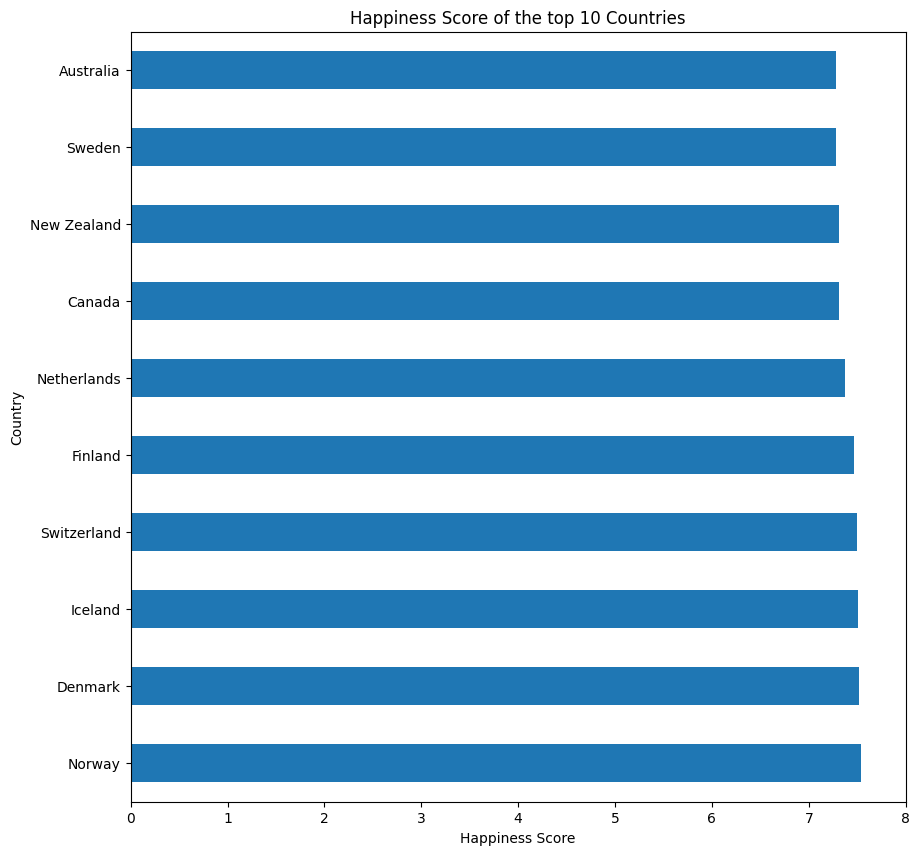

In [182]:
df.set_index('Country')['Happiness Score'].head(10).plot(xticks=np.arange(9), kind='barh', figsize= (10, 10))
plt.xlabel("Happiness Score")
plt.title('Happiness Score of the top 10 Countries')

<Axes: ylabel='Country'>

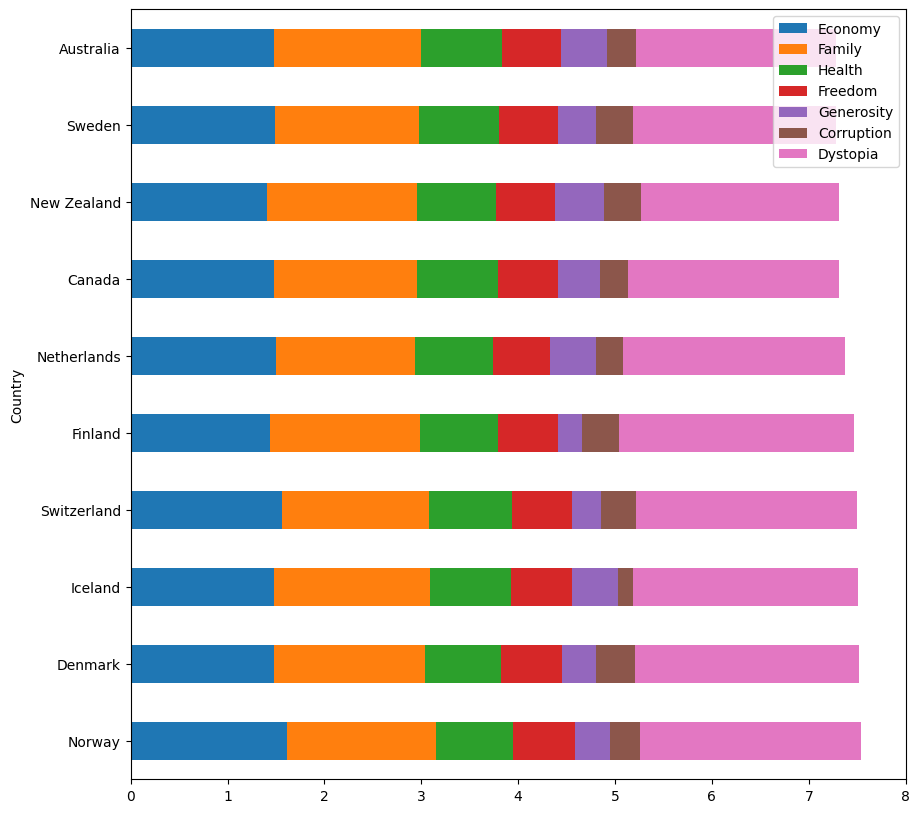

In [183]:
df.set_index('Country')[['Economy','Family','Health','Freedom','Generosity','Corruption','Dystopia']].head(10).plot(xticks=np.arange(9), kind='barh',stacked=True,figsize= (10, 10))

<Axes: ylabel='Country'>

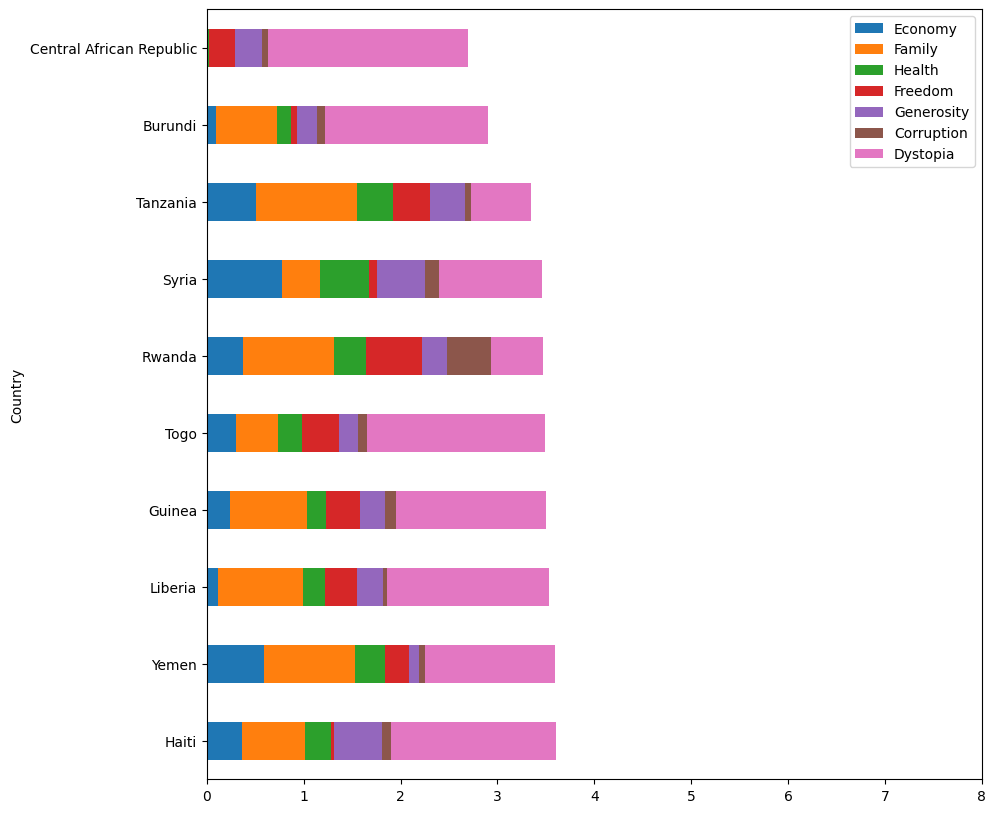

In [184]:
df.set_index('Country')[['Economy','Family','Health','Freedom','Generosity','Corruption','Dystopia']].tail(10).plot(xticks=np.arange(9),kind='barh', stacked=True, figsize=(10,10))

**H.Histogram of Job Satisfaction**

(array([ 5.,  9., 13.,  5.,  8., 24., 21., 27., 22., 17.]),
 array([44.4 , 49.47, 54.54, 59.61, 64.68, 69.75, 74.82, 79.89, 84.96,
        90.03, 95.1 ]),
 <BarContainer object of 10 artists>)

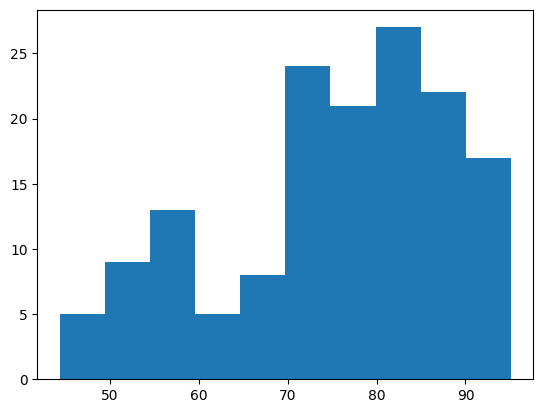

In [185]:
plt.hist(df['Job Satisfaction'])

**I.Pairwise Scatter plots:**

1.Obtain scatter plots of the Happiness Score versus each of the other variables.

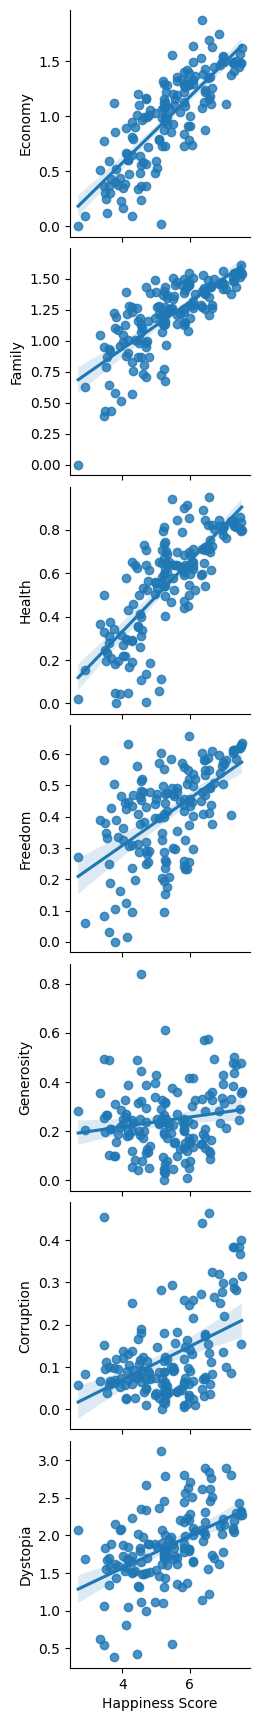

In [186]:
sns.pairplot(data=df, x_vars=['Happiness Score'], y_vars=['Economy','Family','Health','Freedom','Generosity','Corruption','Dystopia'],kind='reg')


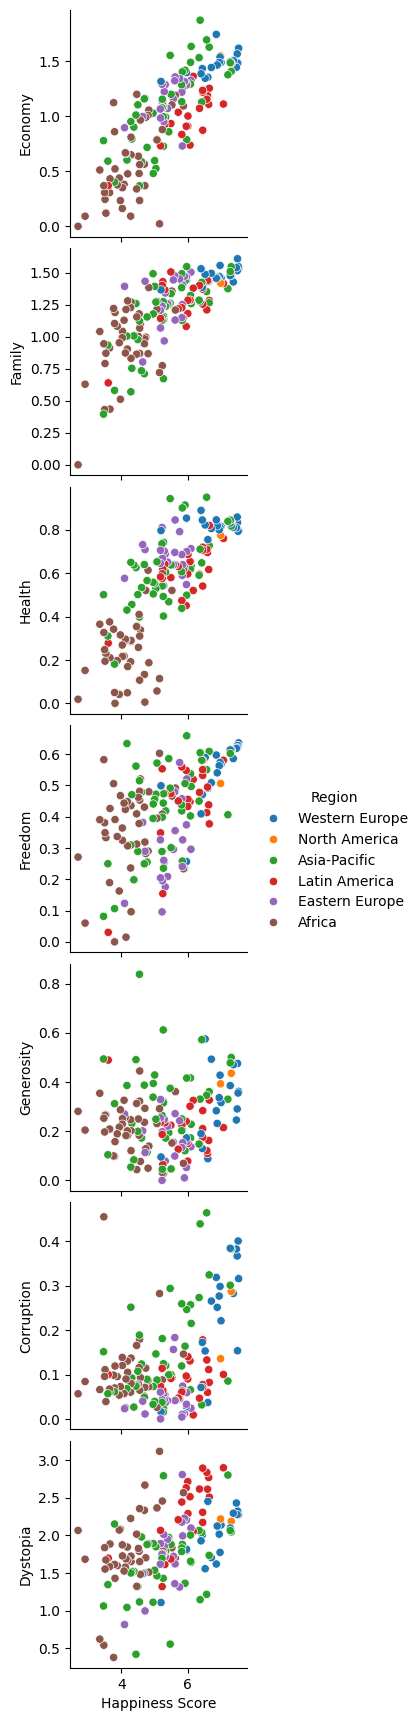

In [187]:
sns.pairplot(data=df, hue='Region',
                  x_vars=['Happiness Score'],
                  y_vars=['Economy', 'Family','Health', 'Freedom', 'Generosity', 'Corruption', 'Dystopia'])

In [188]:
df.corr(numeric_only=True)['Happiness Score']

Happiness Rank     -0.992663
Happiness Score     1.000000
Economy             0.808678
Family              0.749612
Health              0.777731
Freedom             0.567948
Generosity          0.164123
Corruption          0.438262
Dystopia            0.481117
Job Satisfaction    0.812873
Name: Happiness Score, dtype: float64

**J.Heatmap:**

<Axes: >

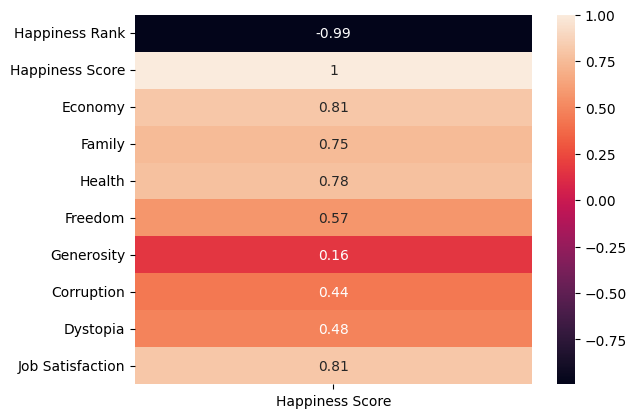

In [189]:
sns.heatmap(df.corr(numeric_only=True)['Happiness Score'].to_frame(),annot=True)

<Axes: >

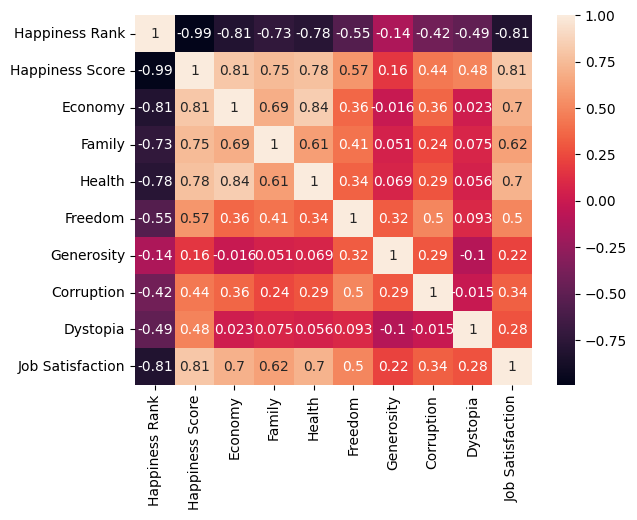

In [190]:
sns.heatmap(df.corr(numeric_only=True),annot=True)